In [1]:
import digitalhub as dh
import pandas as pd
import requests
import os
!pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt

PROJECT = "test-otp-v2"
project = dh.get_or_create_project(PROJECT)

zoi: str = "allBologna"  ## Choose between "allBologna" and "restrictedAv"
method: str = "simplified" ## Choose between "simplified" and "extended"
version: str = "20250926"

In [2]:
df_car_trans_di = project.get_dataitem(f"otp_results_{method}_{zoi}_CAR_PARK_TRANSIT_v{version}")
df_car_trans = df_car_trans_di.as_df()

df_car_di = project.get_dataitem(f"otp_results_{method}_{zoi}_CAR_v{version}")
df_car = df_car_di.as_df()

df_car_park_di = project.get_dataitem(f"otp_results_{method}_{zoi}_CAR_PARK_v{version}")
df_car_park = df_car_park_di.as_df()

df_trans_di = project.get_dataitem(f"otp_results_{method}_{zoi}_TRANSIT_v{version}")
df_trans = df_trans_di.as_df()

print(df_car.columns)

Index(['row_index', 'origin_lat', 'origin_lon', 'from', 'dest_lat', 'dest_lon',
       'to', 'origin_lat_tmp', 'origin_lon_tmp', 'dest_lat_tmp',
       'dest_lon_tmp', 'n_iter', 'status', 'duration_seconds',
       'walk_time_seconds', 'number_of_legs', 'transport_modes',
       'transport_mode_sequences', 'transport_durations',
       'transport_percentages', 'number_of_transit_transfers', 'start_time',
       'end_time'],
      dtype='object')


# CAR E CAR_PARK - allBologna

In [3]:
# Confronto i df in car con e senza park
df_compare = pd.merge(
    df_car_park, 
    df_car, 
    on=['row_index', 'origin_lat', 'origin_lon', 'from', 'dest_lat', 'dest_lon','to'], 
    how='outer',
    suffixes=["_carPark","_car"])

print("N. NAs in car:", int(df_compare["duration_seconds_car"].isna().sum()))
print("N. NAs in carPark:", int(df_compare["duration_seconds_carPark"].isna().sum()))

print("N. success in car:", sum(df_compare["status_car"]=="success"))
print("N. success in carPark:", sum(df_compare["status_carPark"]=="success"))

df_compare.head()

N. NAs in car: 0
N. NAs in carPark: 0
N. success in car: 152
N. success in carPark: 152


,row_index,origin_lat,origin_lon,from,dest_lat,dest_lon,to,origin_lat_tmp_carPark,origin_lon_tmp_carPark,dest_lat_tmp_carPark,...,duration_seconds_car,walk_time_seconds_car,number_of_legs_car,transport_modes_car,transport_mode_sequences_car,transport_durations_car,transport_percentages_car,number_of_transit_transfers_car,start_time_car,end_time_car
0,0,44.109145,10.939834,8037029,44.497006,11.344162,0,44.109145,10.939834,44.497006,...,5051,0,1,[CAR],[],[5051.0],[100.0],0,2025-06-10T07:00:00+02:00,2025-06-10T08:24:11+02:00
1,1,44.149540,10.931946,8037049,44.497006,11.344162,0,44.149540,10.931946,44.497006,...,4380,0,1,[CAR],[],[4380.0],[100.0],0,2025-06-10T07:00:00+02:00,2025-06-10T08:13:00+02:00
2,2,44.150671,11.183166,8037022,44.497006,11.344162,0,44.150671,11.183166,44.497006,...,2351,0,1,[CAR],[],[2351.0],[100.0],0,2025-06-10T07:00:00+02:00,2025-06-10T07:39:11+02:00
3,3,44.152876,11.095953,8037010,44.497006,11.344162,0,44.152876,11.095953,44.497006,...,3357,0,1,[CAR],[],[3357.0],[100.0],0,2025-06-10T07:00:00+02:00,2025-06-10T07:55:57+02:00
4,4,44.159536,11.022521,8037015,44.497006,11.344162,0,44.159536,11.022521,44.497006,...,4075,0,1,[CAR],[],[4075.0],[100.0],0,2025-06-10T07:00:00+02:00,2025-06-10T08:07:55+02:00


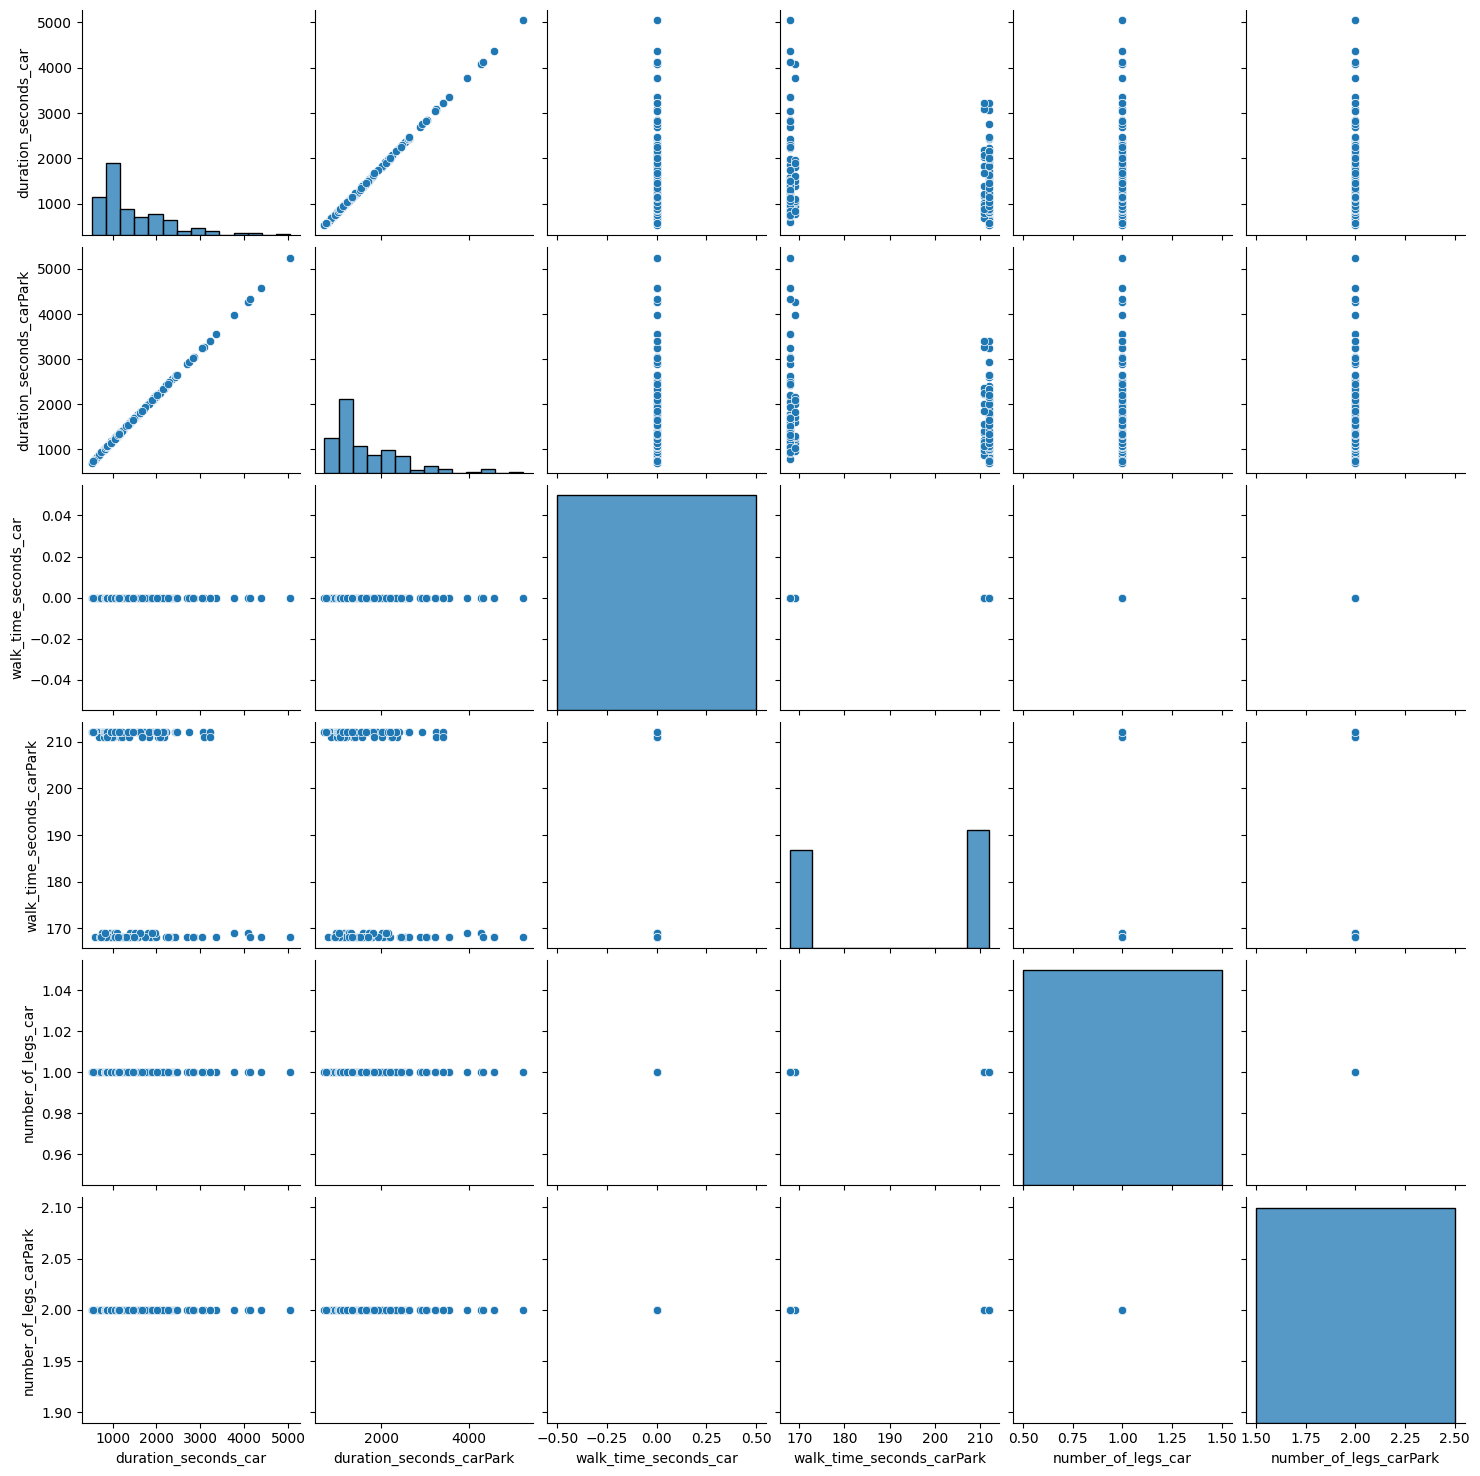

In [4]:
sns.pairplot(
    data=df_compare[["duration_seconds_car", "duration_seconds_carPark",
                        "walk_time_seconds_car", "walk_time_seconds_carPark",
                        "number_of_legs_car", "number_of_legs_carPark"]],
    diag_kind="hist"
)
    

In [5]:
print("Min diff:", min(df_compare["duration_seconds_car"] - df_compare["duration_seconds_carPark"]))
print("Max diff:", max(df_compare["duration_seconds_car"] - df_compare["duration_seconds_carPark"]))
print("Mean diff:", sum(df_compare["duration_seconds_car"] - df_compare["duration_seconds_carPark"])/df_compare.shape[0])

Min diff: -201
Max diff: -180
Mean diff: -189.28947368421052


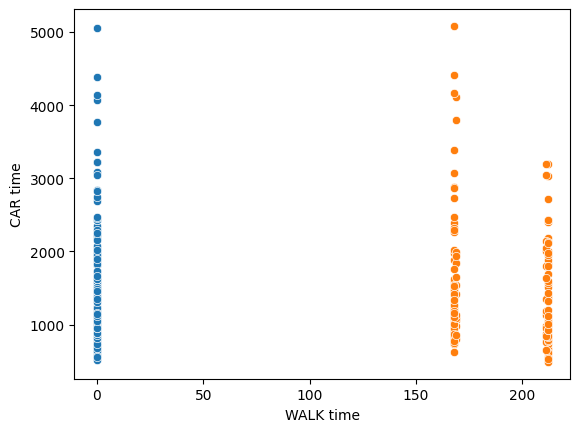

In [6]:
df_compare["CAR_car"] = 0.0
df_compare["WALK_car"] = 0.0
for i, (durations, modes) in enumerate(zip(df_compare["transport_durations_car"], df_compare["transport_modes_car"])):
    for d, m in zip(durations, modes):
        m_mod = f"{m}_car"
        df_compare.loc[i, m_mod] = d
df_compare["CAR_carPark"] = 0.0
df_compare["WALK_carPark"] = 0.0
for i, (durations, modes) in enumerate(zip(df_compare["transport_durations_carPark"], df_compare["transport_modes_carPark"])):
    for d, m in zip(durations, modes):
        m_mod = f"{m}_carPark"
        df_compare.loc[i, m_mod] = d

# Scatterplot
p = sns.scatterplot(data=df_compare, y="CAR_car", x="WALK_car")
p = sns.scatterplot(data=df_compare, y="CAR_carPark", x="WALK_carPark")
p = plt.xlabel("WALK time")
p = plt.ylabel("CAR time")


In [7]:
df_car["waiting_time"] = df_car["duration_seconds"] - df_car["transport_durations"].apply(lambda x: sum(x))
print(df_car["waiting_time"].describe())

df_car_park["waiting_time"] = df_car_park["duration_seconds"] - df_car_park["transport_durations"].apply(lambda x: sum(x))
print(df_car_park["waiting_time"].describe())

df_car_park

count    152.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: waiting_time, dtype: float64
count    152.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: waiting_time, dtype: float64


,row_index,origin_lat,origin_lon,from,dest_lat,dest_lon,to,origin_lat_tmp,origin_lon_tmp,dest_lat_tmp,...,walk_time_seconds,number_of_legs,transport_modes,transport_mode_sequences,transport_durations,transport_percentages,number_of_transit_transfers,start_time,end_time,waiting_time
0,0,44.109145,10.939834,8037029,44.497006,11.344162,0,44.109145,10.939834,44.497006,...,168,2,"[CAR, WALK]",[],"[5083.0, 168.0]","[96.8, 3.2]",0,2025-06-10T07:00:00+02:00,2025-06-10T08:27:31+02:00,0.0
1,1,44.149540,10.931946,8037049,44.497006,11.344162,0,44.149540,10.931946,44.497006,...,168,2,"[CAR, WALK]",[],"[4412.0, 168.0]","[96.33, 3.67]",0,2025-06-10T07:00:00+02:00,2025-06-10T08:16:20+02:00,0.0
2,2,44.150671,11.183166,8037022,44.497006,11.344162,0,44.150671,11.183166,44.497006,...,168,2,"[CAR, WALK]",[],"[2383.0, 168.0]","[93.41, 6.59]",0,2025-06-10T07:00:00+02:00,2025-06-10T07:42:31+02:00,0.0
3,3,44.152876,11.095953,8037010,44.497006,11.344162,0,44.152876,11.095953,44.497006,...,168,2,"[CAR, WALK]",[],"[3389.0, 168.0]","[95.28, 4.72]",0,2025-06-10T07:00:00+02:00,2025-06-10T07:59:17+02:00,0.0
4,4,44.159536,11.022521,8037015,44.497006,11.344162,0,44.159536,11.022521,44.497006,...,169,2,"[CAR, WALK]",[],"[4107.0, 169.0]","[96.05, 3.95]",0,2025-06-10T07:00:00+02:00,2025-06-10T08:11:16+02:00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,147,44.687466,11.509805,8037035,44.497006,11.344162,0,44.687466,11.509805,44.497006,...,212,2,"[CAR, WALK]",[],"[1434.0, 212.0]","[87.12, 12.88]",0,2025-06-10T07:00:00+02:00,2025-06-10T07:27:26+02:00,0.0
148,148,44.710507,11.404958,8037055,44.497006,11.344162,0,44.710507,11.404958,44.497006,...,211,2,"[CAR, WALK]",[],"[1634.0, 211.0]","[88.56, 11.44]",0,2025-06-10T07:00:00+02:00,2025-06-10T07:30:45+02:00,0.0
149,149,44.733801,11.325515,8037048,44.497006,11.344162,0,44.733801,11.325515,44.497006,...,168,2,"[CAR, WALK]",[],"[2286.0, 168.0]","[93.15, 6.85]",0,2025-06-10T07:00:00+02:00,2025-06-10T07:40:54+02:00,0.0
150,150,44.746971,11.429432,8037028,44.497006,11.344162,0,44.746971,11.429432,44.497006,...,212,2,"[CAR, WALK]",[],"[1981.0, 212.0]","[90.33, 9.67]",0,2025-06-10T07:00:00+02:00,2025-06-10T07:36:33+02:00,0.0


# TRANSIT_CAR_PARK - allBologna

In [8]:
# Check, when car_park and transit, the % of times that transit is choosen -> the bus is never chosen!
all_modes = set([])
for modes in df_car_trans["transport_modes"]:
    for m in modes:
        if m not in all_modes:
            all_modes.add(m)
all_modes

{'CAR', 'WALK'}

# TRANSIT - allBologna

In [9]:
# Check transit only
print("N. elements:", df_trans.shape[0])
print("N. elements non successful:", df_trans[df_trans["status"]!="success"].shape[0])
df_trans_nona = df_trans[(df_trans["status"]=="success") & ~(df_trans["row_index"].isna())]
print("N. new elements:", df_trans_nona.shape[0])

N. elements: 152
N. elements non successful: 11
N. new elements: 141


In [10]:
df_trans_nona[["transport_durations"]].apply(lambda x: len(x))

transport_durations    141
dtype: int64

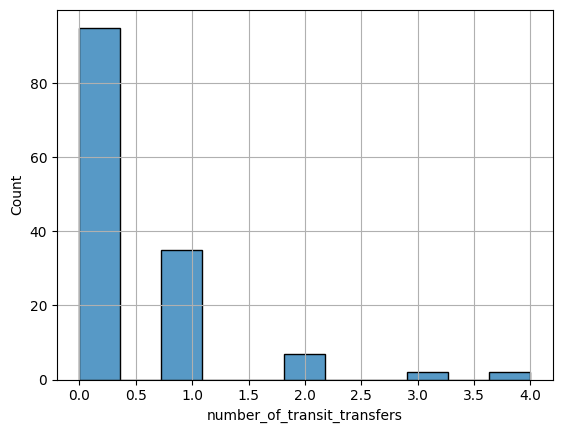

In [11]:
sns.histplot(data=df_trans_nona, x="number_of_transit_transfers")
plt.grid()

<Axes: xlabel='number_of_transit_transfers', ylabel='duration_seconds'>

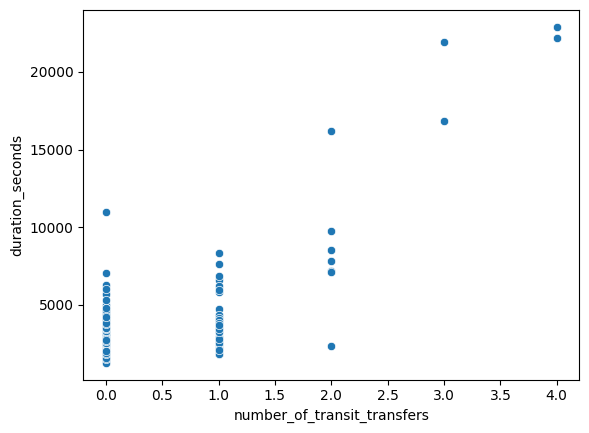

In [12]:
sns.scatterplot(data=df_trans_nona, x="number_of_transit_transfers", y="duration_seconds")

<Axes: >

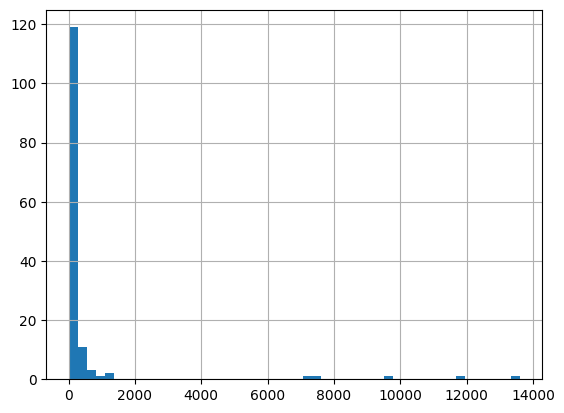

In [13]:
df_trans_nona["waiting_time"] = df_trans_nona["duration_seconds"] - df_trans_nona["transport_durations"].apply(lambda x: sum(x))
df_trans_nona["waiting_time"].hist(bins=50)

<Axes: >

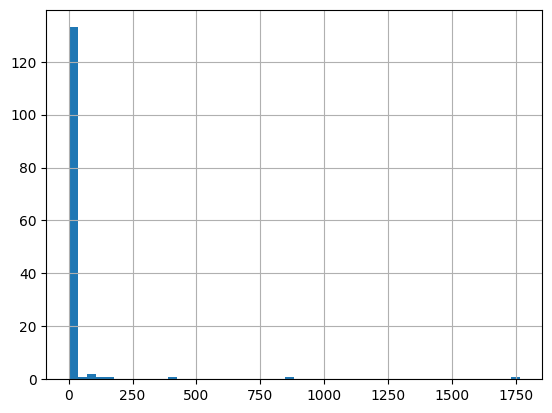

In [14]:
df_trans_nona["change_time"] = 0
for i, row in df_trans_nona.iterrows():
    t = 0
    for a1,a2 in zip( row["transport_durations"][1:-1], row["transport_modes"][1:-1]):
        if a2 == "WALK":
            t = t + a1
    if t > 0:
        df_trans_nona.at[i, "change_time"] = t
df_trans_nona["change_time"].hist(bins=50)

<Axes: >

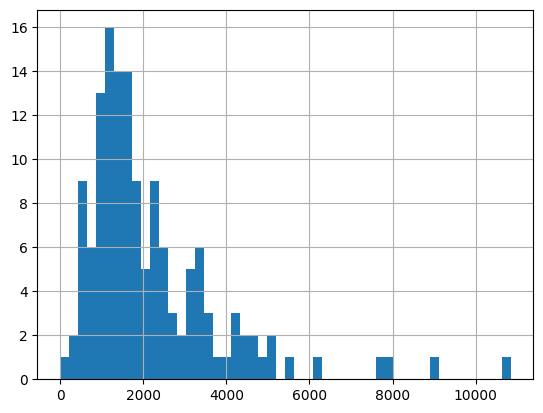

In [15]:
df_trans_nona["onboard_time"] = 0.0
for i, row in df_trans_nona.iterrows():
    t = 0
    for a1,a2 in zip( row["transport_durations"], row["transport_modes"]):
        if a2 == "BUS":
            t = t + a1
    if t > 0:
        df_trans_nona.at[i, "onboard_time"] = t
df_trans_nona["onboard_time"].hist(bins=50)

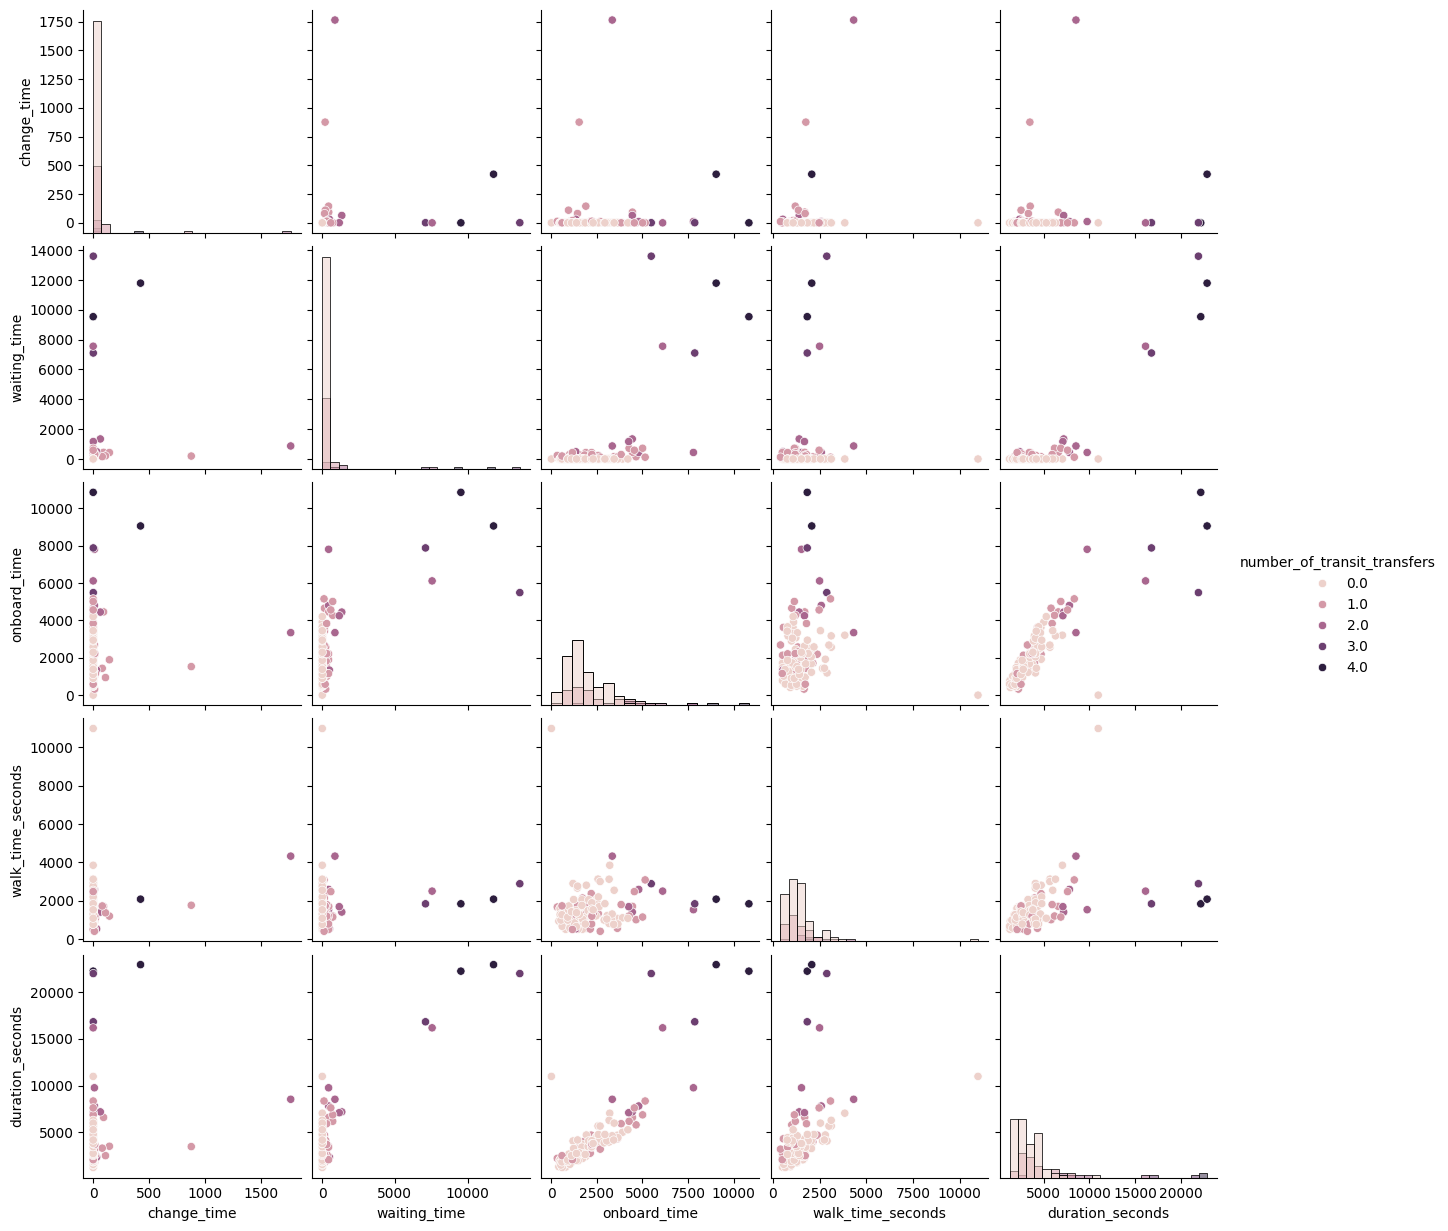

In [16]:
sns.pairplot(
    data=df_trans_nona[["change_time", "waiting_time", "onboard_time", "walk_time_seconds", "duration_seconds", "number_of_transit_transfers"]],
    hue="number_of_transit_transfers",
    diag_kind="hist"
)

In [17]:
df_trans_nona[["change_time", "waiting_time", "onboard_time", "walk_time_seconds", "duration_seconds"]].isna().apply(sum, axis=0)

change_time          0
waiting_time         0
onboard_time         0
walk_time_seconds    0
duration_seconds     0
dtype: int64

# CAR AND TRANSIT

In [18]:
# Check diff between car and transit
df_compare = pd.merge(
    df_car_park,
    df_trans,
    suffixes=["_carPark", "_trans"],
    how="outer",
    on=['row_index', 'origin_lat', 'origin_lon', 'from', 'dest_lat', 'dest_lon','to']
)

print("N. NAs in trans:", int(df_compare["duration_seconds_trans"].isna().sum()))
print("N. NAs in carPark:", int(df_compare["duration_seconds_carPark"].isna().sum()))

print("N. success in trans:", sum(df_compare["status_trans"]=="success"))
print("N. success in carPark:", sum(df_compare["status_carPark"]=="success"))

df_compare = df_compare[df_compare["status_trans"]=="success"]
df_compare.head()

N. NAs in trans: 11
N. NAs in carPark: 0
N. success in trans: 141
N. success in carPark: 152


,row_index,origin_lat,origin_lon,from,dest_lat,dest_lon,to,origin_lat_tmp_carPark,origin_lon_tmp_carPark,dest_lat_tmp_carPark,...,walk_time_seconds_trans,number_of_legs_trans,transport_modes_trans,transport_mode_sequences_trans,transport_durations_trans,transport_percentages_trans,number_of_transit_transfers_trans,start_time_trans,end_time_trans,transport_sequence
0,0,44.109145,10.939834,8037029,44.497006,11.344162,0,44.109145,10.939834,44.497006,...,1834.0,7.0,"[WALK, BUS, BUS, BUS, BUS, BUS, WALK]",[],"[1323.0, 2385.0, 2100.0, 1860.0, 2640.0, 1860....","[10.43, 18.81, 16.56, 14.67, 20.82, 14.67, 4.03]",4.0,2025-06-10T07:53:12+02:00,2025-06-10T14:03:31+02:00,None
2,2,44.150671,11.183166,8037022,44.497006,11.344162,0,44.150671,11.183166,44.497006,...,1527.0,6.0,"[WALK, BUS, BUS, WALK, BUS, WALK]",[],"[1311.0, 4287.0, 3169.0, 11.0, 343.0, 205.0]","[14.06, 45.97, 33.98, 0.12, 3.68, 2.2]",2.0,2025-06-10T07:06:42+02:00,2025-06-10T09:49:25+02:00,None
3,3,44.152876,11.095953,8037010,44.497006,11.344162,0,44.152876,11.095953,44.497006,...,1834.0,7.0,"[WALK, BUS, BUS, WALK, BUS, BUS, WALK]",[],"[1058.0, 1009.0, 1360.0, 1.0, 2334.0, 3169.0, ...","[10.9, 10.4, 14.01, 0.01, 24.05, 32.65, 7.98]",3.0,2025-06-10T07:40:33+02:00,2025-06-10T12:20:44+02:00,None
4,4,44.159536,11.022521,8037015,44.497006,11.344162,0,44.159536,11.022521,44.497006,...,2077.0,8.0,"[WALK, BUS, WALK, BUS, BUS, BUS, BUS, WALK]",[],"[1143.0, 1133.0, 423.0, 1554.0, 1860.0, 2640.0...","[10.28, 10.19, 3.8, 13.97, 16.72, 23.73, 16.72...",4.0,2025-06-10T07:41:38+02:00,2025-06-10T14:03:31+02:00,None
6,6,44.217239,11.321332,8037040,44.497006,11.344162,0,44.217239,11.321332,44.497006,...,1005.0,4.0,"[WALK, BUS, BUS, WALK]",[],"[347.0, 4175.0, 475.0, 658.0]","[6.14, 73.83, 8.4, 11.64]",1.0,2025-06-10T07:24:13+02:00,2025-06-10T09:00:58+02:00,None


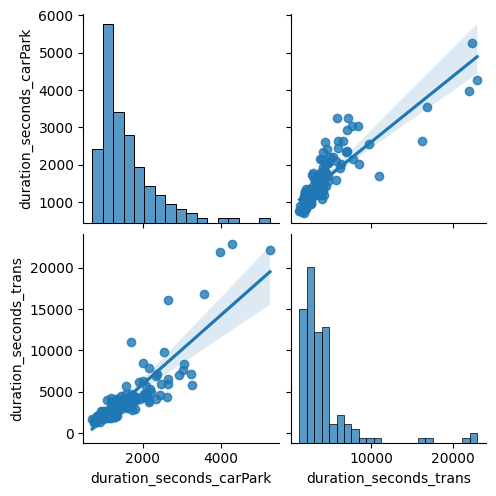

In [19]:
sns.pairplot(
    data=df_compare[["duration_seconds_carPark", "duration_seconds_trans"]],
    kind="reg"
)

# Not allBologna, but restrictedAv

In [20]:
zoi: str = "restrictedAv"  ## Choose between "allBologna" and "restrictedAv"
method: str = "simplified" ## Choose between "simplified" and "extended"
version: str = "20250930"

In [21]:
df_car_trans_di = project.get_dataitem(f"otp_results_{method}_{zoi}_CAR_PARK_TRANSIT_v{version}")
df_car_trans = df_car_trans_di.as_df()

df_car_di = project.get_dataitem(f"otp_results_{method}_{zoi}_CAR_v{version}")
df_car = df_car_di.as_df()

df_car_park_di = project.get_dataitem(f"otp_results_{method}_{zoi}_CAR_PARK_v{version}")
df_car_park = df_car_park_di.as_df()

df_trans_di = project.get_dataitem(f"otp_results_{method}_{zoi}_TRANSIT_v{version}")
df_trans = df_trans_di.as_df()

print(df_car.columns)

Index(['row_index', 'origin_lat', 'origin_lon', 'from', 'dest_lat', 'dest_lon',
       'to', 'origin_lat_tmp', 'origin_lon_tmp', 'dest_lat_tmp',
       'dest_lon_tmp', 'n_iter', 'status', 'duration_seconds',
       'walk_time_seconds', 'number_of_legs', 'transport_modes',
       'transport_mode_sequences', 'transport_sequence', 'transport_durations',
       'transport_percentages', 'number_of_transit_transfers', 'start_time',
       'end_time', 'mode_change_points', 'mode_change_coordinates',
       'mode_change_names'],
      dtype='object')


In [22]:
df_car_park["status"].value_counts()

status
success           151
no_itineraries      1
Name: count, dtype: int64

In [23]:
print(df_car["status"].value_counts())
df_car[df_car["status"]=="success"]

status
no_itineraries    152
Name: count, dtype: int64


,row_index,origin_lat,origin_lon,from,dest_lat,dest_lon,to,origin_lat_tmp,origin_lon_tmp,dest_lat_tmp,...,transport_mode_sequences,transport_sequence,transport_durations,transport_percentages,number_of_transit_transfers,start_time,end_time,mode_change_points,mode_change_coordinates,mode_change_names


In [24]:
print(df_car_trans["status"].value_counts())
df_car_trans[df_car_trans["status"]=="success"].head()

status
success           151
no_itineraries      1
Name: count, dtype: int64


,row_index,origin_lat,origin_lon,from,dest_lat,dest_lon,to,origin_lat_tmp,origin_lon_tmp,dest_lat_tmp,...,transport_mode_sequences,transport_durations,transport_percentages,number_of_transit_transfers,start_time,end_time,mode_change_points,mode_change_coordinates,mode_change_names,transport_sequence
0,0,44.109145,10.939834,8037029,44.497006,11.344162,0,44.109145,10.939834,44.497006,...,[],"[4999.0, 1317.0]","[79.15, 20.85]",0.0,2025-06-10T07:00:00+02:00,2025-06-10T08:45:16+02:00,"[{'from_mode': None, 'lat': 44.1091453, 'lon':...","[(44.109145, 10.939834), (44.484941, 11.340597...","[Origin, P+R (#2), Destination]",None
1,1,44.149540,10.931946,8037049,44.497006,11.344162,0,44.149540,10.931946,44.497006,...,[],"[4329.0, 1317.0]","[76.67, 23.33]",0.0,2025-06-10T07:00:00+02:00,2025-06-10T08:34:06+02:00,"[{'from_mode': None, 'lat': 44.1495396, 'lon':...","[(44.149540, 10.931946), (44.484941, 11.340597...","[Origin, P+R (#2), Destination]",None
2,2,44.150671,11.183166,8037022,44.497006,11.344162,0,44.150671,11.183166,44.497006,...,[],"[1729.0, 133.0, 1320.0, 511.0]","[46.82, 3.6, 35.74, 13.84]",0.0,2025-06-10T07:53:58+02:00,2025-06-10T08:55:31+02:00,"[{'from_mode': None, 'lat': 44.1506714, 'lon':...","[(44.150671, 11.183166), (44.478403, 11.275272...","[Origin, P+R (#2), CASALECCHIO CASA CONOSCENZA...",None
3,3,44.152876,11.095953,8037010,44.497006,11.344162,0,44.152876,11.095953,44.497006,...,[],"[3748.0, 1316.0]","[74.01, 25.99]",0.0,2025-06-10T07:00:00+02:00,2025-06-10T08:24:24+02:00,"[{'from_mode': None, 'lat': 44.1528764, 'lon':...","[(44.152876, 11.095954), (44.484941, 11.340597...","[Origin, P+R (#2), Destination]",None
4,4,44.159536,11.022521,8037015,44.497006,11.344162,0,44.159536,11.022521,44.497006,...,[],"[4063.0, 1316.0]","[75.53, 24.47]",0.0,2025-06-10T07:00:00+02:00,2025-06-10T08:29:39+02:00,"[{'from_mode': None, 'lat': 44.1595361, 'lon':...","[(44.159536, 11.022521), (44.484941, 11.340597...","[Origin, P+R (#2), Destination]",None


In [25]:
#Confronta car park con car park transit nel caso di AV ristretta -> comparabili? Competitivi?
df_compare = pd.merge(
    df_car_trans,
    df_car_park,
    suffixes=["_carParkTrans", "_carPark"],
    how="outer",
    on=['row_index', 'origin_lat', 'origin_lon', 'from', 'dest_lat', 'dest_lon','to']
)

print("N. NAs in carParkTrans:", int(df_compare["duration_seconds_carParkTrans"].isna().sum()))
print("N. NAs in carPark:", int(df_compare["duration_seconds_carPark"].isna().sum()))

print("N. success in carParkTrans:", sum(df_compare["status_carParkTrans"]=="success"))
print("N. success in carPark:", sum(df_compare["status_carPark"]=="success"))

df_compare = df_compare[df_compare["status_carParkTrans"]=="success"]
df_compare.head()


N. NAs in carParkTrans: 1
N. NAs in carPark: 1
N. success in carParkTrans: 151
N. success in carPark: 151


,row_index,origin_lat,origin_lon,from,dest_lat,dest_lon,to,origin_lat_tmp_carParkTrans,origin_lon_tmp_carParkTrans,dest_lat_tmp_carParkTrans,...,transport_mode_sequences_carPark,transport_durations_carPark,transport_percentages_carPark,number_of_transit_transfers_carPark,start_time_carPark,end_time_carPark,mode_change_points_carPark,mode_change_coordinates_carPark,mode_change_names_carPark,transport_sequence_carPark
0,0,44.109145,10.939834,8037029,44.497006,11.344162,0,44.109145,10.939834,44.497006,...,[],"[4999.0, 1317.0]","[79.15, 20.85]",0.0,2025-06-10T07:00:00+02:00,2025-06-10T08:45:16+02:00,"[{'from_mode': None, 'lat': 44.1091453, 'lon':...","[(44.109145, 10.939834), (44.484941, 11.340597...","[Origin, P+R (#1), Destination]",None
1,1,44.149540,10.931946,8037049,44.497006,11.344162,0,44.149540,10.931946,44.497006,...,[],"[4329.0, 1317.0]","[76.67, 23.33]",0.0,2025-06-10T07:00:00+02:00,2025-06-10T08:34:06+02:00,"[{'from_mode': None, 'lat': 44.1495396, 'lon':...","[(44.149540, 10.931946), (44.484941, 11.340597...","[Origin, P+R (#1), Destination]",None
2,2,44.150671,11.183166,8037022,44.497006,11.344162,0,44.150671,11.183166,44.497006,...,[],"[2725.0, 1317.0]","[67.42, 32.58]",0.0,2025-06-10T07:00:00+02:00,2025-06-10T08:07:22+02:00,"[{'from_mode': None, 'lat': 44.1506714, 'lon':...","[(44.150671, 11.183166), (44.484941, 11.340597...","[Origin, P+R (#1), Destination]",None
3,3,44.152876,11.095953,8037010,44.497006,11.344162,0,44.152876,11.095953,44.497006,...,[],"[3748.0, 1316.0]","[74.01, 25.99]",0.0,2025-06-10T07:00:00+02:00,2025-06-10T08:24:24+02:00,"[{'from_mode': None, 'lat': 44.1528764, 'lon':...","[(44.152876, 11.095954), (44.484941, 11.340597...","[Origin, P+R (#1), Destination]",None
4,4,44.159536,11.022521,8037015,44.497006,11.344162,0,44.159536,11.022521,44.497006,...,[],"[4063.0, 1316.0]","[75.53, 24.47]",0.0,2025-06-10T07:00:00+02:00,2025-06-10T08:29:39+02:00,"[{'from_mode': None, 'lat': 44.1595361, 'lon':...","[(44.159536, 11.022521), (44.484941, 11.340597...","[Origin, P+R (#1), Destination]",None


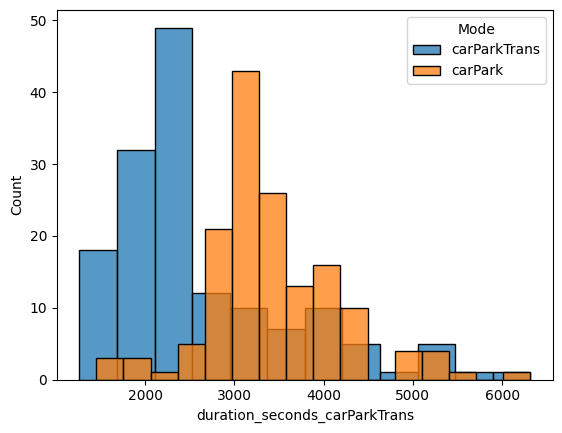

In [26]:
sns.histplot(data=df_compare, x="duration_seconds_carParkTrans")
sns.histplot(data=df_compare, x="duration_seconds_carPark")
plt.legend(labels=["carParkTrans", "carPark"], title="Mode")

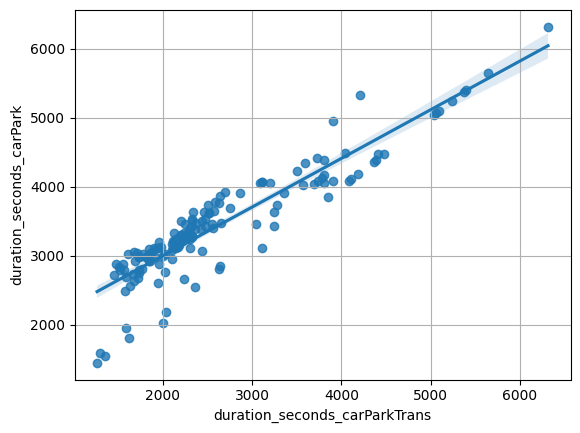

In [27]:
sns.regplot(data=df_compare, x="duration_seconds_carParkTrans", y="duration_seconds_carPark")
plt.grid()

# CAR_TRANSIT - restrictedAv and allBologna

In [67]:
zoi: str = "restrictedAv"
method: str = "simplified" ## Choose between "simplified" and "extended"
version: str = "20250930"

df_rest_di = project.get_dataitem(f"otp_results_{method}_{zoi}_CAR_PARK_TRANSIT_v{version}")
df_rest = df_rest_di.as_df()
print(df_rest[df_rest["status"]=="success"].shape[0])
print(df.columns)

151
Index(['row_index_restricted', 'origin_lat', 'origin_lon', 'from', 'dest_lat',
       'dest_lon', 'to', 'origin_lat_tmp_restricted',
       'origin_lon_tmp_restricted', 'dest_lat_tmp_restricted',
       'dest_lon_tmp_restricted', 'n_iter_restricted', 'status_restricted',
       'duration_seconds_restricted', 'walk_time_seconds_restricted',
       'number_of_legs_restricted', 'transport_modes_restricted',
       'transport_mode_sequences_restricted', 'transport_durations_restricted',
       'transport_percentages_restricted',
       'number_of_transit_transfers_restricted', 'start_time_restricted',
       'end_time_restricted', 'mode_change_points', 'mode_change_coordinates',
       'mode_change_names', 'transport_sequence', 'row_index_all',
       'origin_lat_tmp_all', 'origin_lon_tmp_all', 'dest_lat_tmp_all',
       'dest_lon_tmp_all', 'n_iter_all', 'status_all', 'duration_seconds_all',
       'walk_time_seconds_all', 'number_of_legs_all', 'transport_modes_all',
       'transport_

In [58]:
!pip install geopandas
!pip install shapely
!pip install contextily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.4/125.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 63.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.7/40.7 kB 3.1 MB/s eta 0:00:00


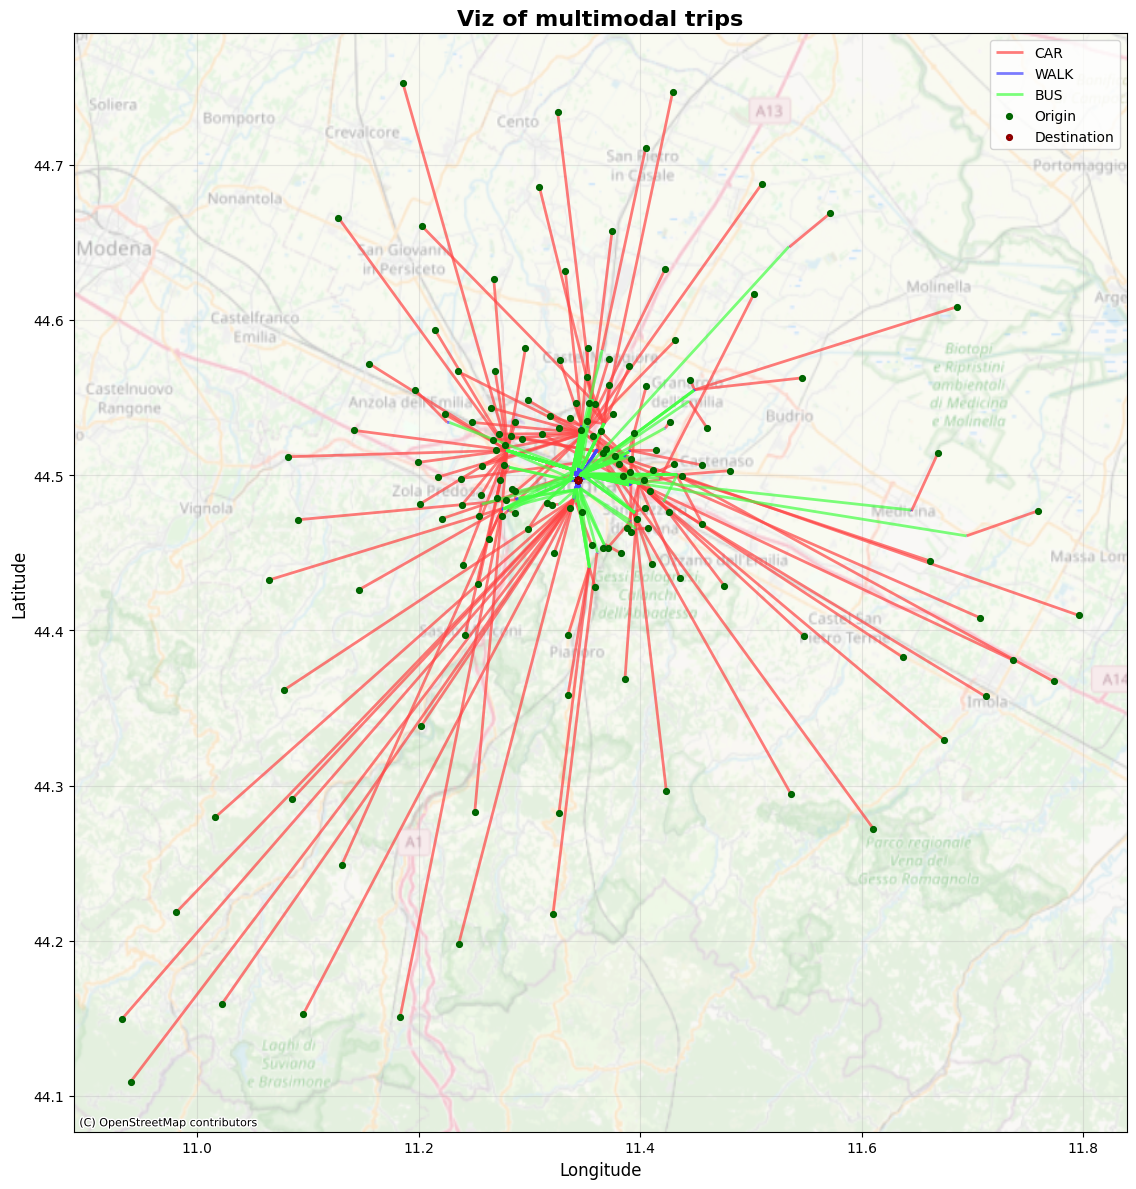

In [73]:
import geopandas as gpd
from shapely.geometry import LineString, Point
import matplotlib.pyplot as plt
import contextily as ctx
import ast

df_sample = df_rest[df_rest["status"]=="success"]

# Color map for modes
transport_colors = {
    'CAR': '#FF4444',
    'WALK': '#4444FF',
    'BUS': '#44FF44',
    'TRANSIT': '#44FF44'
}

# For each trip in the sample, create the linestring of the trip
segments_list = []

for idx, row in df_sample.iterrows():
    coords_str = row['mode_change_coordinates']
    transport_modes = row['transport_modes']
    
    # Converti la stringa in lista di tuple
    if isinstance(coords_str, str):
        coords = ast.literal_eval(coords_str)
    else:
        coords = coords_str
    
    # Crea un segmento per ogni tratta del viaggio
    for i in range(len(coords) - 1):
        start_point = coords[i]
        end_point = coords[i + 1]
        
        # Se i punti sono stringhe, convertili in tuple
        if isinstance(start_point, str):
            start_point = ast.literal_eval(start_point)
        if isinstance(end_point, str):
            end_point = ast.literal_eval(end_point)
        
        # Determina la modalità di trasporto per questo segmento
        if i < len(transport_modes):
            mode = transport_modes[i]
            color = transport_colors.get(mode, '#888888')
        else:
            mode = 'UNKNOWN'
            color = '#888888'
        
        # Crea LineString per il segmento (nota: shapely usa (lon, lat))
        line = LineString([(start_point[1], start_point[0]), 
                          (end_point[1], end_point[0])])
        
        segments_list.append({
            'geometry': line,
            'trip_id': idx,
            'segment_id': i,
            'mode': mode,
            'color': color
        })

# Create the geodataframe
gdf_segments = gpd.GeoDataFrame(segments_list, crs='EPSG:4326')

# Create marker for OD
origins = []
destinations = []

for idx, row in df_sample.iterrows():
    coords_str = row['mode_change_coordinates']
    
    if isinstance(coords_str, str):
        coords = ast.literal_eval(coords_str)
    else:
        coords = coords_str
    
    # Converti i punti se sono stringhe
    first_coord = coords[0]
    last_coord = coords[-1]
    
    if isinstance(first_coord, str):
        first_coord = ast.literal_eval(first_coord)
    if isinstance(last_coord, str):
        last_coord = ast.literal_eval(last_coord)
    
    # Origin
    origins.append({
        'geometry': Point(first_coord[1], first_coord[0]),
        'trip_id': idx,
        'type': 'origin'
    })
    # Dest
    destinations.append({
        'geometry': Point(last_coord[1], last_coord[0]),
        'trip_id': idx,
        'type': 'destination'
    })

gdf_origins = gpd.GeoDataFrame(origins, crs='EPSG:4326')
gdf_destinations = gpd.GeoDataFrame(destinations, crs='EPSG:4326')

# PLOT
fig, ax = plt.subplots(figsize=(15, 12))

# Add trip segments
for mode in gdf_segments['mode'].unique():
    gdf_mode = gdf_segments[gdf_segments['mode'] == mode]
    color = gdf_mode.iloc[0]['color']
    gdf_mode.plot(ax=ax, color=color, linewidth=2, alpha=0.7, label=mode)

# Plot OD points
gdf_origins.plot(ax=ax, color='green', markersize=10, 
                 label='Origin', zorder=5, edgecolor='darkgreen', linewidth=2)
gdf_destinations.plot(ax=ax, color='red', markersize=10, 
                      label='Destination', zorder=5, edgecolor='darkred', linewidth=2)

# Add basemap
ctx.add_basemap(ax, crs=gdf_segments.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik, zoom=10, alpha=0.4)

# Plot configuration
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('Viz of multimodal trips', fontsize=16, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [29]:
df_rest[df_rest["status"]!="success"] # From 50 to Bologna there is no path. What is zone 50?

,row_index,origin_lat,origin_lon,from,dest_lat,dest_lon,to,origin_lat_tmp,origin_lon_tmp,dest_lat_tmp,...,transport_mode_sequences,transport_durations,transport_percentages,number_of_transit_transfers,start_time,end_time,mode_change_points,mode_change_coordinates,mode_change_names,transport_sequence
50,50,44.46903,11.36308,75,44.497006,11.344162,0,44.46903,11.36181,44.497006,...,[],[],[],NaN,None,None,[],[],[],


In [30]:
zoi: str = "allBologna"
method: str = "simplified" ## Choose between "simplified" and "extended"
version: str = "20250926"

df_all_di = project.get_dataitem(f"otp_results_{method}_{zoi}_CAR_PARK_TRANSIT_v{version}")
df_all = df_all_di.as_df()
print(df_all[df_all["status"]=="success"].shape[0])

152


In [38]:
merge_cols = df_all.columns[1:7].to_list()
df = pd.merge(df_rest[df_rest["status"]=="success"], df_all[df_all["status"]=="success"], on=merge_cols, suffixes=["_restricted","_all"])
df.head()

,row_index_restricted,origin_lat,origin_lon,from,dest_lat,dest_lon,to,origin_lat_tmp_restricted,origin_lon_tmp_restricted,dest_lat_tmp_restricted,...,duration_seconds_all,walk_time_seconds_all,number_of_legs_all,transport_modes_all,transport_mode_sequences_all,transport_durations_all,transport_percentages_all,number_of_transit_transfers_all,start_time_all,end_time_all
0,0,44.109145,10.939834,8037029,44.497006,11.344162,0,44.109145,10.939834,44.497006,...,5251,168,2,"[CAR, WALK]",[],"[5083.0, 168.0]","[96.8, 3.2]",0,2025-06-10T07:00:00+02:00,2025-06-10T08:27:31+02:00
1,1,44.149540,10.931946,8037049,44.497006,11.344162,0,44.149540,10.931946,44.497006,...,4580,168,2,"[CAR, WALK]",[],"[4412.0, 168.0]","[96.33, 3.67]",0,2025-06-10T07:00:00+02:00,2025-06-10T08:16:20+02:00
2,2,44.150671,11.183166,8037022,44.497006,11.344162,0,44.150671,11.183166,44.497006,...,2551,168,2,"[CAR, WALK]",[],"[2383.0, 168.0]","[93.41, 6.59]",0,2025-06-10T07:00:00+02:00,2025-06-10T07:42:31+02:00
3,3,44.152876,11.095953,8037010,44.497006,11.344162,0,44.152876,11.095953,44.497006,...,3557,168,2,"[CAR, WALK]",[],"[3389.0, 168.0]","[95.28, 4.72]",0,2025-06-10T07:00:00+02:00,2025-06-10T07:59:17+02:00
4,4,44.159536,11.022521,8037015,44.497006,11.344162,0,44.159536,11.022521,44.497006,...,4276,169,2,"[CAR, WALK]",[],"[4107.0, 169.0]","[96.05, 3.95]",0,2025-06-10T07:00:00+02:00,2025-06-10T08:11:16+02:00


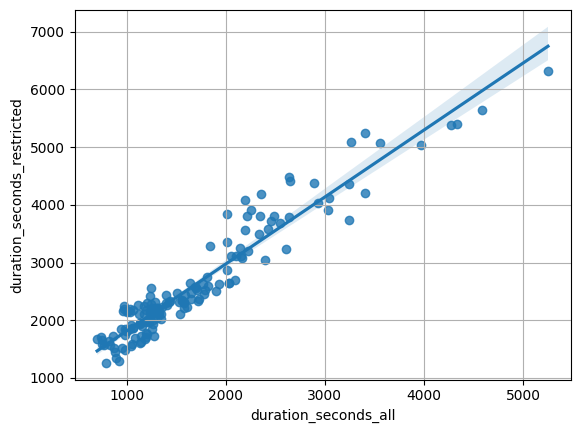

In [40]:
sns.regplot(data=df, x="duration_seconds_all", y="duration_seconds_restricted")
plt.grid()